In [1]:
import matplotlib.pyplot as plt
#from src.TimeSeriesAnalysis import *
#from src.process_data import summarize_all_dirs, create_folder, process_all_data
from IPython.display import clear_output
from src.TimeSeriesAnalysis import load_properties_bundle, create_folder
plt.style.use('properties.mplstyle')
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, LinearLocator,FormatStrFormatter
from matplotlib.lines import Line2D
#from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from tqdm import tqdm
import pandas as pd
import os
import numpy as np

In [2]:
results = "../results/study"
create_folder(results)

In [3]:
df = pd.read_csv("../SOP_data/all_data.dat", sep=' ')
df = df.dropna()
df = df[df['N_samples']==df['N_samples_perc']]
df

,type_perc,dim,L,f_T,c,nc,rho,p0,P0,order,N_samples,N_samples_perc,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
26,bond,2,8192,0.071983,0.01,1,1.000,0.6,0.1,1,20,20,0.500434,0.000007,32747.35,1187.871179,1.752333e+07,8.124360e+05
34,bond,2,8192,0.083814,0.01,1,1.000,0.6,0.1,1,20,20,0.500344,0.000007,30685.10,915.258905,1.888285e+07,7.447281e+05
38,bond,2,8192,0.089729,0.01,1,1.000,0.6,0.1,1,20,20,0.500352,0.000007,30231.50,873.029904,1.944677e+07,1.145008e+06
42,bond,2,8192,0.095644,0.01,1,1.000,0.6,0.1,1,20,20,0.500401,0.000006,27421.10,461.432112,1.884806e+07,7.013492e+05
46,bond,2,8192,0.101559,0.01,1,1.000,0.6,0.1,1,20,20,0.500453,0.000006,28919.35,483.353947,2.127903e+07,6.496668e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25037,bond,3,320,0.275083,0.50,8,0.125,0.6,0.1,6,102,102,1.000000,0.000000,319.00,0.000000,4.736957e+04,9.196291e+02
25038,bond,3,320,0.275083,0.50,8,0.125,0.6,0.1,7,102,102,1.000000,0.000000,319.00,0.000000,4.946024e+04,1.029659e+03
25039,bond,3,320,0.275083,0.50,8,0.125,0.6,0.1,8,102,102,1.000000,0.000000,319.00,0.000000,4.832250e+04,1.013991e+03
25040,node,3,16,0.060000,0.01,1,1.000,1.0,0.1,1,3,3,0.993478,0.000044,15.00,0.000000,3.385000e+03,2.487971e+01


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def power_law_offset(x, A, B, beta):
    return A + B * x**beta


def fit_power_law_offset(x, y, p0=None, bounds=(-np.inf, np.inf), plot=True):
    """
    Ajusta o modelo:
        y_fit = A + B*x^beta

    Parâmetros
    ----------
    x, y : array-like
        Dados a serem ajustados.
    p0 : tuple ou list, opcional
        Chute inicial para (A, B, beta).
    bounds : tuple, opcional
        Limites para os parâmetros no formato usado por curve_fit.
    plot : bool
        Se True, plota os dados e o ajuste.

    Retorna
    -------
    result : dict
        Dicionário com parâmetros ajustados, erros e qualidade do ajuste.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Remove NaN e inf
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    # Para beta não inteiro, x precisa ser positivo
    if np.any(x <= 0):
        raise ValueError("O modelo x^beta com beta real exige x > 0.")

    # Ordena os dados por x
    idx = np.argsort(x)
    x = x[idx]
    y = y[idx]

    # Chute inicial automático, se não for fornecido
    if p0 is None:
        A0 = y[-1]              # bom chute se y tende a um platô
        B0 = y[0] - A0
        beta0 = -1.0            # útil para convergência assintótica
        p0 = (A0, B0, beta0)

    popt, pcov = curve_fit(
        power_law_offset,
        x,
        y,
        p0=p0,
        bounds=bounds,
        maxfev=100000
    )

    A, B, beta = popt
    perr = np.sqrt(np.diag(pcov))

    y_fit = power_law_offset(x, A, B, beta)

    residuals = y - y_fit
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot

    result = {
        "A": A,
        "B": B,
        "beta": beta,
        "A_err": perr[0],
        "B_err": perr[1],
        "beta_err": perr[2],
        "r2": r2,
        "x_fit": x,
        "y_fit": y_fit,
        "covariance": pcov
    }

    if plot:
        plt.figure(figsize=(8, 6))

        plt.plot(x, y, "o", label="data")
        plt.plot(
            x,
            y_fit,
            "-",
            label=rf"$A + Bx^\beta$, $\beta={beta:.4f}$"
        )

        plt.xlabel(r"$x$")
        plt.ylabel(r"$y$")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return result

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def model_power(x, A, B, beta):
    return A + B * x**beta


def model_quadratic(x, A, B, C):
    return A + B*x + C*x**2


def model_exponential(x, A, B, C):
    return A + B * (np.exp(C*x) - 1)


def calc_metrics(y, yfit, n_params):
    residuals = y - yfit
    rss = np.sum(residuals**2)
    n = len(y)

    rmse = np.sqrt(rss / n)

    # AIC para erro gaussiano com variância desconhecida
    aic = n * np.log(rss / n) + 2 * n_params

    # AIC corrigido para amostra pequena
    aicc = aic + (2 * n_params * (n_params + 1)) / (n - n_params - 1)

    return rss, rmse, aic, aicc


def compare_fits(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    idx = np.argsort(x)
    x = x[idx]
    y = y[idx]

    results = {}

    # -------------------------
    # Modelo 1: A + B x^beta
    # -------------------------
    popt_power, pcov_power = curve_fit(
        model_power,
        x,
        y,
        p0=(y.min(), y.max() - y.min(), 2.0),
        bounds=([-np.inf, -np.inf, 0.0], [np.inf, np.inf, np.inf]),
        maxfev=100000
    )

    yfit_power = model_power(x, *popt_power)
    results["power"] = {
        "params": popt_power,
        "errors": np.sqrt(np.diag(pcov_power)),
        "yfit": yfit_power,
        "metrics": calc_metrics(y, yfit_power, 3)
    }

    # -------------------------
    # Modelo 2: A + B x + C x^2
    # -------------------------
    popt_quad, pcov_quad = curve_fit(
        model_quadratic,
        x,
        y,
        p0=(y.min(), 0.0, 1.0),
        maxfev=100000
    )

    yfit_quad = model_quadratic(x, *popt_quad)
    results["quadratic"] = {
        "params": popt_quad,
        "errors": np.sqrt(np.diag(pcov_quad)),
        "yfit": yfit_quad,
        "metrics": calc_metrics(y, yfit_quad, 3)
    }

    # -------------------------
    # Modelo 3: A + B(exp(Cx)-1)
    # -------------------------
    popt_exp, pcov_exp = curve_fit(
        model_exponential,
        x,
        y,
        p0=(y.min(), y.max() - y.min(), 5.0),
        maxfev=100000
    )

    yfit_exp = model_exponential(x, *popt_exp)
    results["exponential"] = {
        "params": popt_exp,
        "errors": np.sqrt(np.diag(pcov_exp)),
        "yfit": yfit_exp,
        "metrics": calc_metrics(y, yfit_exp, 3)
    }

    # -------------------------
    # Imprimir comparação
    # -------------------------
    print("Comparação dos ajustes:")
    print("-" * 70)
    print(f"{'modelo':<15} {'RSS':>15} {'RMSE':>15} {'AICc':>15}")
    print("-" * 70)

    for name, res in results.items():
        rss, rmse, aic, aicc = res["metrics"]
        print(f"{name:<15} {rss:>15.6e} {rmse:>15.6e} {aicc:>15.6f}")

    print("-" * 70)

    # -------------------------
    # Plot
    # -------------------------
    x_dense = np.linspace(x.min(), x.max(), 500)

    plt.figure(figsize=(8, 6))
    plt.plot(x, y, "o", label="data")

    plt.plot(
        x_dense,
        model_power(x_dense, *results["power"]["params"]),
        "-",
        label=r"$A + Bx^\beta$"
    )

    plt.plot(
        x_dense,
        model_quadratic(x_dense, *results["quadratic"]["params"]),
        "--",
        label=r"$A + Bx + Cx^2$"
    )

    plt.plot(
        x_dense,
        model_exponential(x_dense, *results["exponential"]["params"]),
        ":",
        label=r"$A + B(e^{Cx}-1)$"
    )

    plt.xlabel(r"$x$")
    plt.ylabel(r"$y$")
    plt.legend()
    plt.tight_layout()
    #plt.axhline(y=1.0)
    plt.show()
    
    return results

Comparação dos ajustes:
----------------------------------------------------------------------
modelo                      RSS            RMSE            AICc
----------------------------------------------------------------------
power              8.105326e-03    1.273211e-02     -429.841109
quadratic          3.419123e-02    2.615004e-02     -357.868714
exponential        7.783957e-04    3.945620e-03     -546.993189
----------------------------------------------------------------------


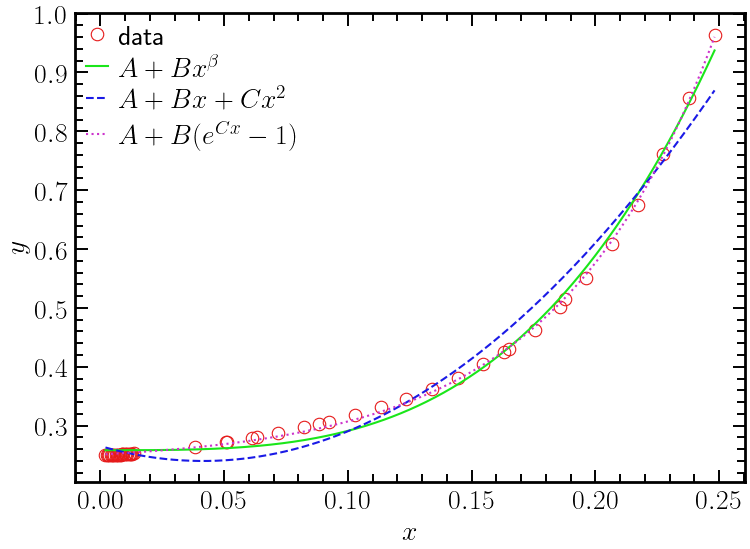

In [43]:
L_lst = [256, 512, 1024]
#L_lst = [256]
c = 0.05
nc_lst = [1, 2, 4, 8]
p0 = 0.6
P0 = 0.1
nc = 4
rho = 1/nc
dim = 3
f_TMAX = 0.25

L = 1024
df_b = df[(df['nc']==nc) & (df['L']==L) & (df['c']==c) & (df['type_perc']=='bond') & 
            (df['p0']==p0) & (df['P0']==P0) & (df['order']==1) & (df['rho']==rho) & (df['dim']==dim)].sort_values('f_T')
df_b = df_b[df_b['f_T']<=f_TMAX]


df_plot = df_b.sort_values("p_mean").reset_index(drop=True)
idx = df_plot.index[df_plot["p_mean"] >= 1.0]
if len(idx) > 0:
    idx_cut = idx[0]
    df_trunc = df_plot.loc[:idx_cut].copy()
else:
    df_trunc = df_plot.copy()

x = df_trunc['f_T'] #f_t
y = df_trunc['p_mean'] #p_t

results = compare_fits(x, y)

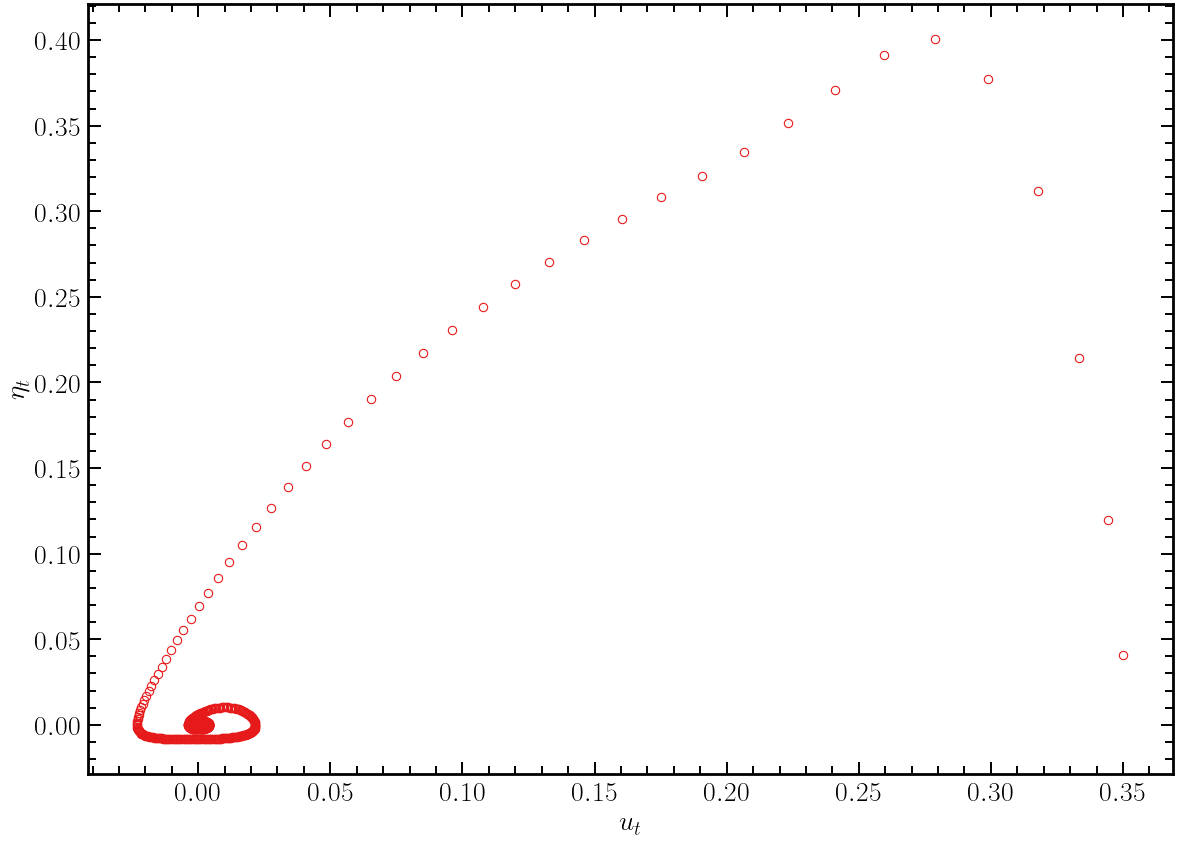

In [58]:
L = 1024
c = 0.05
ns  = 2
p0 = 0.6
P0 = 0.1
rho = 1/ns
type_perc = 'bond'
dim = 3
fT = 0.009305553
p0_target = 0.6
P0_target = 0.1
path = (
    f"../SOP_data/published/{type_perc}_percolation/"
    f"num_colors_{ns}/dim_{dim}/L_{L}/"
    f"fT_constant/fT_{fT:.6e}/"
    f"c_{c:.6e}/rho_{rho:.4e}/"
)

fn = "properties_mean_bundle.json"
bundle = load_properties_bundle(path + fn)
order_mean = 0
data = bundle[p0]["orders"][order_mean]
p = data['pt_mean']
f = data['ft_mean']
p_ = data['pc_sop']['mean']
u_t = np.array(p) - p_
eta_t = np.array(f) - fT
plt.plot(u_t, eta_t, 'o', ms=6)
plt.xlabel('$u_t$')
plt.ylabel(r'$\eta_t$')
plt.savefig('teste.pdf')
plt.show()